# Comparaison des résultats

## 3 scénarios de coûts

Scénario 1 : Projections 2050 dans le cadre de l'évaluation du scénario négaWatt

Scénario 2 : Coûts actuels (2024) fournis par RTE

Scénario 3 : Coûts projetés en 2050 sur les hypothèses RTE

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Résultats nW 2050
results_1 = pd.read_csv('results.csv', index_col=0)
results_1.head()

#Résultats RTE 2025
results_2 = pd.read_csv('results2026.csv', index_col = 0)

#Résultats RTE 2050
results_3 = pd.read_csv('RTE2050/results2026.csv', index_col=0)


In [54]:
results_3.head()

,Installed power [GW],Energy capacity [GWh],Generated energy [TWh],Load factor [%],FCR [TWh],FRR [TWh],lcoe [€/MWh],lcoe without input [€/MWh]
offshore_float,6.291957e-13,NaN,NaN,NaN,NaN,NaN,No new plants,NaN
offshore_ground,2.276864e-12,NaN,NaN,NaN,NaN,NaN,No new plants,NaN
onshore,1.200000e+02,NaN,318.793430,30.326620,NaN,NaN,47.686815545787695,NaN
pv_ground_S,9.500000e+01,NaN,134.868557,16.206267,NaN,NaN,51.04548888546558,NaN
pv_ground_EW,9.503035e-11,NaN,NaN,NaN,NaN,NaN,No new plants,NaN


In [55]:
installed_power_nW = results_1['Installed power [GW]']
installed_power_2025 = results_2['Installed power [GW]']
installed_power_2050 = results_3['Installed power [GW]']

In [56]:
installed_power_nW = installed_power_nW.fillna(0)
installed_power_2025 = installed_power_2025.fillna(0)
installed_power_2050 = installed_power_2050.fillna(0)

In [57]:
installed_power = installed_power_nW.to_frame()
installed_power['scénario RTE 2025'] = installed_power_2025
installed_power['scénario RTE 2050'] = installed_power_2050
installed_power['scénario nW'] = installed_power_nW
installed_power = installed_power.drop(columns = 'Installed power [GW]')
installed_power = installed_power.sort_values(by='scénario nW')

Histogramme

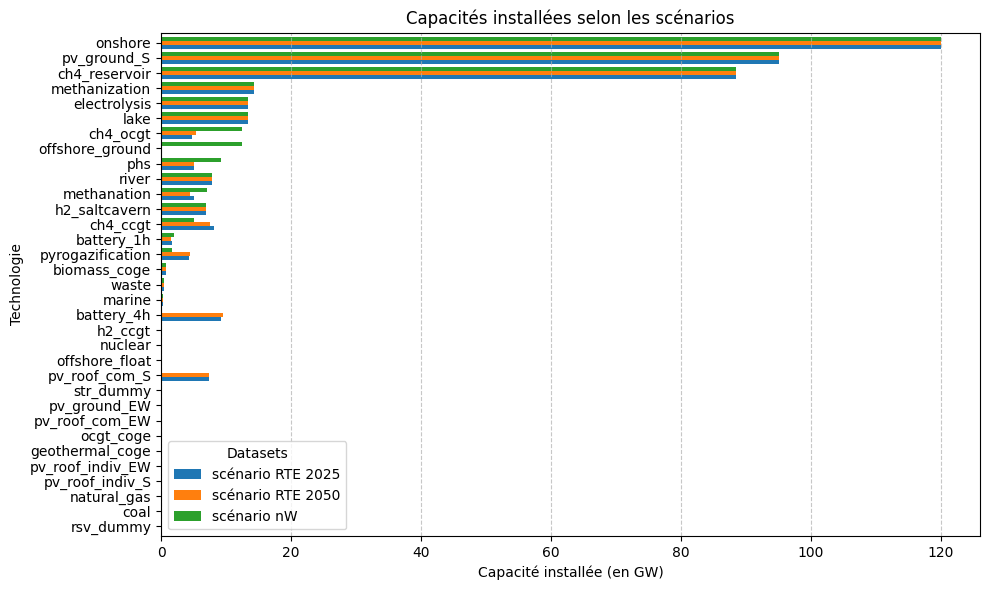

In [58]:
ax = installed_power.plot(kind="barh", figsize=(10, 6), width=0.8)

plt.title("Capacités installées selon les scénarios")
plt.xlabel("Capacité installée (en GW)")
plt.ylabel("Technologie")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.legend(title="Datasets")

plt.tight_layout()
plt.show()

In [59]:
installed_power = installed_power.drop(['rsv_dummy', 'coal', 'natural_gas', 'ocgt_coge'])

Enlever les lignes où tout est en dessous de $10^{-6}$

In [60]:
installed_power = installed_power[~(installed_power <= 1e-6).all(axis=1)]

Enlever les lignes où tout est égal

In [61]:
#installed_power = installed_power[~installed_power.apply(lambda row: all(row == row.iloc[0]), axis=1)]

In [62]:
#installed_power = installed_power.drop(['methanization', 'electrolysis'])

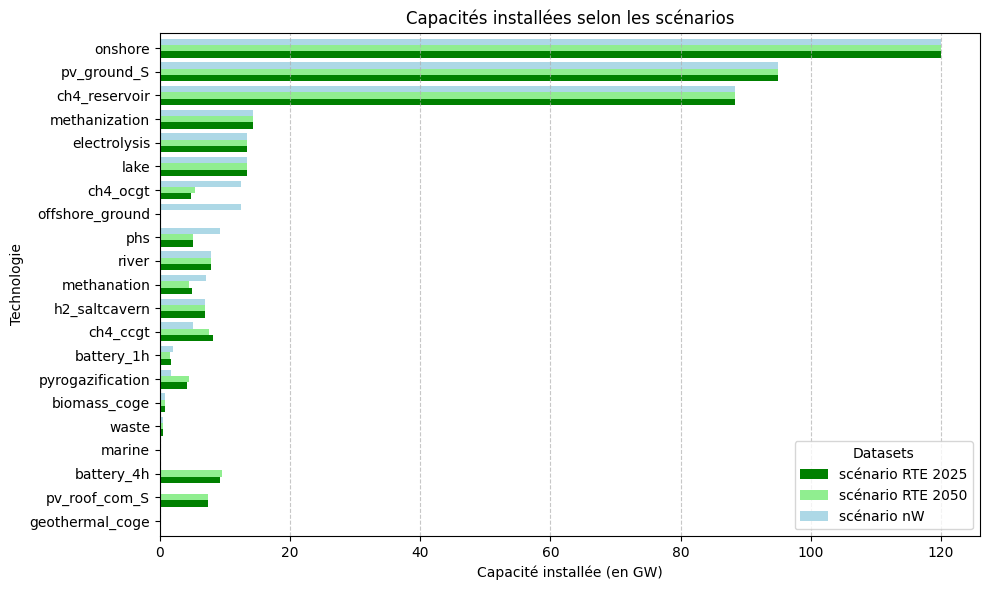

In [63]:
ax = installed_power.plot(kind="barh", figsize=(10, 6), width=0.8,
             color=["green", "lightgreen", "lightblue"])

plt.title("Capacités installées selon les scénarios")
plt.xlabel("Capacité installée (en GW)")
plt.ylabel("Technologie")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.legend(title="Datasets")

plt.tight_layout()
plt.show()

## Generated Energy

In [64]:
gen_energy = results_1['Generated energy [TWh]']
gen_energy = gen_energy.to_frame()
gen_energy['scénario RTE 2025'] = results_2['Generated energy [TWh]']
gen_energy['scénario RTE 2050'] = results_3['Generated energy [TWh]']
gen_energy['scénario nW'] = results_1['Generated energy [TWh]']
gen_energy = gen_energy.drop(columns = 'Generated energy [TWh]')
gen_energy = gen_energy.fillna(0)
gen_energy = gen_energy.sort_values(by='scénario nW')
gen_energy = gen_energy[~(gen_energy <= 1e-6).all(axis=1)]

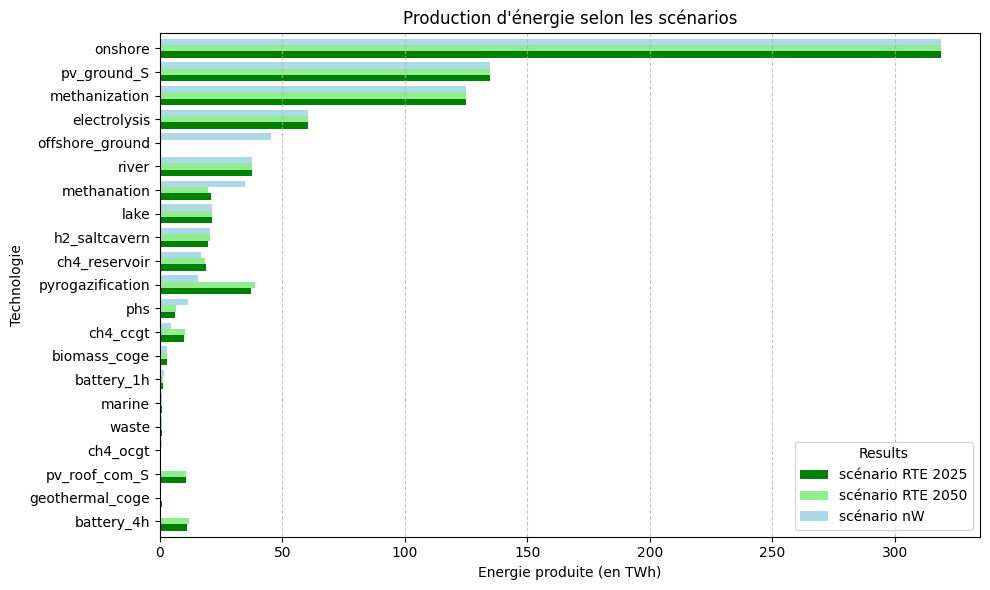

In [65]:
ax = gen_energy.plot(kind="barh", figsize=(10, 6), width=0.8,
             color=["green", "lightgreen", "lightblue"])

plt.title("Production d'énergie selon les scénarios")
plt.xlabel("Energie produite (en TWh)")
plt.ylabel("Technologie")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.legend(title="Results")

plt.tight_layout()
plt.show()